# Taller 5 - Aprendizaje Supervisado: Clasificación o Regresión
## Alumna: Abril Gabriela de los Angeles Sanchez Perez
## Cohorte 202604 

In [1]:
# Paso 0. Importacion de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para este ejercicio he decidio usar los regresores:

# A. Regresion Lineal: Esto para asumir una relación lineal entres las variables como kilometraje, año y potencia con el precio. 
# Esto para poder establecer en que punto mejoran los otros
from sklearn.linear_model import LinearRegression

# B. Arbol de decisiones: Para poder establecer reglas en datos de forma no lineal, por ejemplo
# si año > 2015 y km <50000 entonces Type 1. 

from sklearn.tree import DecisionTreeRegressor

# C. Random Forest Regressor: Conjunto de muchos arboles de decision entrenados con distintos modelos de datos.
# reduce un overfiting causado por el arbol de decisiones. 
from sklearn.ensemble import RandomForestRegressor

# Las herramientas para poder trabajar el preprocesamiento de los datos son las siguientes.

# División de los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Escalador para normalizar variables numéricas antes de entrenar
from sklearn.preprocessing import StandardScaler

# Y las métricas para poder evaluar las predicciones del modelo serán: 

# R2: % de variación del precio (Lo hace de 0 a 1 y mientras más cerca esté de 1, mejor)
from sklearn.metrics import r2_score

# MSE: mide el promedio de los errores al cuadrado entre el precio real y el predicho. Penaliza más los errores grandes.
from sklearn.metrics import mean_squared_error

In [2]:
# Paso 1. Carga de Datos y Análisis Exploratorio Inicial

dataframe = pd.read_csv ('cardekho.csv')

# Miras las 5 primeras filas del dataset para saber que tiene:

print('Filas existentes en el dataset')
print(dataframe.head())

Filas existentes en el dataset
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78    5.0  
3

In [3]:
# .info para saber cuales son los tipos de datos que se manejan en el dataframe.
print('Tipo de datos existentes:')
print(dataframe.info())

Tipo de datos existentes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB
None


In [4]:
# isnull para saber si existen datos nulos en el dataframe.
print ('Datos Nulos existentes')
print(dataframe.isnull().sum())

Datos Nulos existentes
name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64


In [5]:
# .describe para saber las estadísticas del dataframe.
print('Estadisticas en los datos')
print(dataframe.describe())

Estadisticas en los datos
              year  selling_price     km_driven  mileage(km/ltr/kg)  \
count  8128.000000   8.128000e+03  8.128000e+03         7907.000000   
mean   2013.804011   6.382718e+05  6.981951e+04           19.418783   
std       4.044249   8.062534e+05  5.655055e+04            4.037145   
min    1983.000000   2.999900e+04  1.000000e+00            0.000000   
25%    2011.000000   2.549990e+05  3.500000e+04           16.780000   
50%    2015.000000   4.500000e+05  6.000000e+04           19.300000   
75%    2017.000000   6.750000e+05  9.800000e+04           22.320000   
max    2020.000000   1.000000e+07  2.360457e+06           42.000000   

            engine        seats  
count  7907.000000  7907.000000  
mean   1458.625016     5.416719  
std     503.916303     0.959588  
min     624.000000     2.000000  
25%    1197.000000     5.000000  
50%    1248.000000     5.000000  
75%    1582.000000     5.000000  
max    3604.000000    14.000000  


In [6]:
# .nunique para saber cuantos datos unicos existen.
print('Valores unicos en el Dataframe')
print(dataframe.select_dtypes(include=object).nunique())

Valores unicos en el Dataframe
name            2058
fuel               4
seller_type        3
transmission       2
owner              5
max_power        320
dtype: int64


In [7]:
# Siguiente paso: Como existen datos nulos en las columnas de mileage (km/ltr/kg), engine, max_power y seats
# es necesario conocer si es necesario o no conservar los datos. Si este porcentaje equivale a menos del 5% de
# los datos, se podrán eliminar haciendo uso de la opción .dropna, de lo contrario se deberán transformar.

datos_nulos= (dataframe['mileage(km/ltr/kg)'].isnull().sum() / len(dataframe))*100
print(f'% Datos nulos en mileage: {datos_nulos:.2f}%')

% Datos nulos en mileage: 2.72%


In [8]:
# Como los datos representan menos del 5% de todo el dataframe, es justo eliminarlos. 
# Para esto uso la formula .dropna.

dataframe = dataframe.dropna()

# Y procedo a observar que ya no queden datos nulos en todo el dataframe,
print('\nValores nulos existentes luego de la limpieza')
print(dataframe.isnull().sum())

print('\nNueva dimension del Dataframe:', dataframe.shape)


Valores nulos existentes luego de la limpieza
name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

Nueva dimension del Dataframe: (7907, 12)


In [9]:
# Al devolverme al inicio de la exploración del dataframe, noté que existe una columna aparentemente
# en valores pero el tipo está en object: *10  max_power 7913 non-null object*
# por lo que se debe hacer una eliminación de estos valores. 

# Para poder volverlo a número se debe combinar las funciones pd.to_numeric y errors=coerce,
# esto ultimo para poder evitar que se pare la función cuando se trate de correr la celda. 

dataframe['max_power'] = pd.to_numeric(dataframe['max_power'], errors='coerce')

# Ahora, verifico cuantos nulos reales existen tras usar estas formulas
print ('Valores nulos luego del to numeric')
print(dataframe['max_power'].isnull().sum())

Valores nulos luego del to numeric
1


In [10]:
# Ahora realizo el dropna para poder eliminar el valor ya que solo 1 valor nulo NO afecta en nada. 

dataframe = dataframe.dropna()

# Y procedo a mirar nuevamente la dimension del dataframe. 

print("\nDimensión final del dataset:", dataframe.shape)


Dimensión final del dataset: (7906, 12)


In [11]:
# Paso 2. Preprocesamiento de Datos e Ingeniería de Características

# Es necesario primeramente identificar que tipo de datos existen por las categorías a usar, esto para saber si existen jerarquías entre cada dato y poder hacer
# One-Hot Encoding y Ordinal Encoding de acuerdo a lo que corresponde, esto volviendo a usar la funcion unique()

print("Categorías en 'fuel':", dataframe['fuel'].unique())
print("Categorías en 'seller_type':", dataframe['seller_type'].unique())
print("Categorías en 'transmission':", dataframe['transmission'].unique())
print("Categorías en 'owner':", dataframe['owner'].unique())

Categorías en 'fuel': ['Diesel' 'Petrol' 'LPG' 'CNG']
Categorías en 'seller_type': ['Individual' 'Dealer' 'Trustmark Dealer']
Categorías en 'transmission': ['Manual' 'Automatic']
Categorías en 'owner': ['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']


In [12]:
# Haciendo enfásis en la categoría 'owner' ya que existe una clara jerarquía, parece ser que, a medida que tiene menos dueños el auto es más valioso
# por lo que no se pueden tratar como variables sin relación entre sí y es necesario mapearlas con números (En mi caso del 0 al 4) primero haciendo un diccionario

mapa_owner = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4
}

# Y con la función .map reemplanzando los textos por el numero asignado
dataframe['owner'] = dataframe['owner'].map(mapa_owner)

print ("Valores en Owner luego del mapeo:")
print(dataframe['owner'].unique())

Valores en Owner luego del mapeo:
[1 2 3 4 0]


In [13]:
# Una vez realizado el Ordinal Encoding, esto debido a que las demás variables no tienen relaciones entre sí y asignarles valores númericos podría interpretarse como si existe 
# una relación falsa entre ellos. Para esto el One Hot Encoding que crea una columna nueva de 1 y 0 para cada categoría. 

# Ahora también se debe usar el drop_first=True para poder evitar ser redundantes. 

dataframe = pd.get_dummies(dataframe, columns=['fuel', 'seller_type', 'transmission'], drop_first=True)

print("Columnas después del One-Hot Encoding:")
print(dataframe.columns.tolist())

Columnas después del One-Hot Encoding:
['name', 'year', 'selling_price', 'km_driven', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual']


In [14]:
# Luego de esto y como paso para poder realizar el modelado tambien es necesario eliminar la columna 'name' esto debido a que cada modelo de auto es distinto.
# Evitando a caer en la alta cardinalidad.

dataframe = dataframe.drop(columns=['name'])

print("Columnas finales del dataset:")
print(dataframe.columns.tolist())

print("\nVista previa del dataset luego de los encoding, ya 100% numérico:")
print(dataframe.head())

Columnas finales del dataset:
['year', 'selling_price', 'km_driven', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual']

Vista previa del dataset luego de los encoding, ya 100% numérico:
   year  selling_price  km_driven  owner  mileage(km/ltr/kg)  engine  \
0  2014         450000     145500      1               23.40  1248.0   
1  2014         370000     120000      2               21.14  1498.0   
2  2006         158000     140000      3               17.70  1497.0   
3  2010         225000     127000      1               23.00  1396.0   
4  2007         130000     120000      1               16.10  1298.0   

   max_power  seats  fuel_Diesel  fuel_LPG  fuel_Petrol  \
0      74.00    5.0         True     False        False   
1     103.52    5.0         True     False        False   
2      78.00    5.0        False     False         True   
3      90

In [15]:
# Paso 3.  División del Dataset

# En este dataset existen dos tipos de variables: la predictora (selling_price) y las objetivos (todas las demas). Es necesario separarlas en el eje y y x para comenzar a realizar 
# el entrenamiento. 

X = dataframe.drop(columns=['selling_price'])  # Todo excepto el precio
y = dataframe['selling_price']                  # Lo que quiero predecir

print("Forma de X (features):", X.shape)
print("Forma de y (target):", y.shape)

Forma de X (features): (7906, 13)
Forma de y (target): (7906,)


In [16]:
# Una vez definidos los ejes x - y, es necesario establecer el % de los datos que se va a usar para prueba y el % que se usará para probarlos. De esta forma me aseguro que el modelo
# no tome el 100% de los datos, los memorice y cree patrones generalizados

# test_size=0.2 -> 80% de los datos para entrenar, 20% para probar

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTamaño de entrenamiento (train):", X_train.shape)
print("Tamaño de prueba (test):", X_test.shape)


Tamaño de entrenamiento (train): (6324, 13)
Tamaño de prueba (test): (1582, 13)


In [17]:
# Ahora es necesario poder hacer el Escalado de datos, esto es parte del ejercicio de regresión lineal como la columna 'km_driven' tiene valores muy grandes, es necesario un StandardScaler a X.

scaler = StandardScaler() # Crea variables con una media de 0 a 1 , para crear una "igualdad de condiciones"

X_train_scaled = scaler.fit_transform(X_train) # .fit_transform() en X_train el escalador APRENDE (calcula media y desviación estándar) SOLO de los datos de entrenamiento, y los transforma.
X_test_scaled = scaler.transform(X_test) # No se usa el .fit para evitar que el modelo vea la info del dataset de prueba.

print("Ejemplo de valores ANTES de escalar (primera fila de X_train):")
print(X_train.iloc[0])

print("\nEjemplo de valores DESPUÉS de escalar (primera fila de X_train_scaled):")
print(X_train_scaled[0])

Ejemplo de valores ANTES de escalar (primera fila de X_train):
year                             2006
km_driven                       62900
owner                               1
mileage(km/ltr/kg)               18.9
engine                          998.0
max_power                        67.1
seats                             5.0
fuel_Diesel                     False
fuel_LPG                        False
fuel_Petrol                      True
seller_type_Individual           True
seller_type_Trustmark Dealer    False
transmission_Manual              True
Name: 3064, dtype: object

Ejemplo de valores DESPUÉS de escalar (primera fila de X_train_scaled):
[-2.05489382 -0.12291363 -0.62803963 -0.12321444 -0.91752339 -0.68732596
 -0.43983016 -1.10124302 -0.06787364  1.12474129  0.44950288 -0.1745592
  0.38895173]


In [18]:
# Paso 4. Entrenamiento de Modelos

# Modelo 1. Regresion Lineal: Baseline, Asume que el precio es una combinación
# lineal de las variables. Es rápido, fácil de interpretar, pero limitado si la relación real entre las variables y el precio no es lineal (en autos usados es común
# que el valor no baje de forma constante con los km, sino que se desplome más rápido al principio).

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_scaled, y_train)  # .fit() = "entrena" el modelo

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# Modelo 2. Arbol de Decisiones: Divide los datos en reglas tipo "si-entonces" de forma automática, puede capturar relaciones no lineales, pero un solo árbol tiende a 
# sobreajustarse (overfitting): memoriza demasiado el set de entrenamiento y generaliza peor a datos nuevos

modelo_arbol = DecisionTreeRegressor(random_state=42)
modelo_arbol.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [20]:
# Modelo 3. Random Forest: Entrena MUCHOS árboles de decisión (por defecto 100), cada uno con una muestra distinta de los datos y de las variables, y luego PROMEDIA sus predicciones.
# Evita el sobreajuste y da un mejor balance entre precision y capacidad de generalizar.

modelo_forest = RandomForestRegressor(random_state=42)
modelo_forest.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
# Paso 5. Evaluación y Comparación de Resultados

# Ahora es necesario usar el modelo que se entrenó para poder predecir el precio de los autos, esto para simular un escenario real. 

pred_lineal = modelo_lineal.predict(X_test_scaled)
pred_arbol = modelo_arbol.predict(X_test_scaled)
pred_forest = modelo_forest.predict(X_test_scaled)

print("Predicciones generadas para los 3 modelos.")
print("\nPrimeras 5 predicciones - Regresión Lineal:", pred_lineal[:5])
print("Primeras 5 predicciones - Árbol de Decisión:", pred_arbol[:5])
print("Primeras 5 predicciones - Random Forest:", pred_forest[:5])
print("\nPrimeros 5 valores REALES (y_test):", y_test.values[:5])

Predicciones generadas para los 3 modelos.

Primeras 5 predicciones - Regresión Lineal: [ 651594.56567243  421440.48411051   87169.47616269  408995.12122339
 1078913.59935753]
Primeras 5 predicciones - Árbol de Decisión: [650000. 510000. 168000. 415000. 620000.]
Primeras 5 predicciones - Random Forest: [564869.95       518653.32333333 163869.96       338499.99
 587178.55142857]

Primeros 5 valores REALES (y_test): [501000 440000 140000 476999 620000]


In [22]:
# Calculo con las métricas de evaluación

from sklearn.metrics import mean_absolute_error

def calcular_metricas(y_real, y_pred, nombre_modelo):
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    print(f"--- {nombre_modelo} ---")
    print(f"R2:   {r2:.4f}")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}\n")
    return {"Modelo": nombre_modelo, "R2": r2, "MAE": mae, "RMSE": rmse}

resultados = []
resultados.append(calcular_metricas(y_test, pred_lineal, "Regresión Lineal"))
resultados.append(calcular_metricas(y_test, pred_arbol, "Árbol de Decisión"))
resultados.append(calcular_metricas(y_test, pred_forest, "Random Forest"))

tabla_resultados = pd.DataFrame(resultados)
print("Tabla comparativa de métricas:")
print(tabla_resultados)

--- Regresión Lineal ---
R2:   0.6950
MAE:  270,007.25
RMSE: 460,483.47

--- Árbol de Decisión ---
R2:   0.9653
MAE:  73,646.22
RMSE: 155,310.07

--- Random Forest ---
R2:   0.9836
MAE:  61,147.46
RMSE: 106,822.68

Tabla comparativa de métricas:
              Modelo        R2            MAE           RMSE
0   Regresión Lineal  0.695023  270007.247260  460483.465798
1  Árbol de Decisión  0.965307   73646.219869  155310.071548
2      Random Forest  0.983588   61147.458501  106822.684969


# Conclusiones Finales - Gráficas para entender el resultado

De una forma más visual, se realizarán gráficas que permitan comparar cuál es el mejor modelo. A simple vista quien obtuvo los mejores resultados es el Random Forest

Tiene el R² más alto (explica el 98.36% de la variabilidad del precio), el MAE más bajo (se equivoca en promedio por "solo" 61,147) y el RMSE más bajo (mejor control incluso sobre los errores grandes).

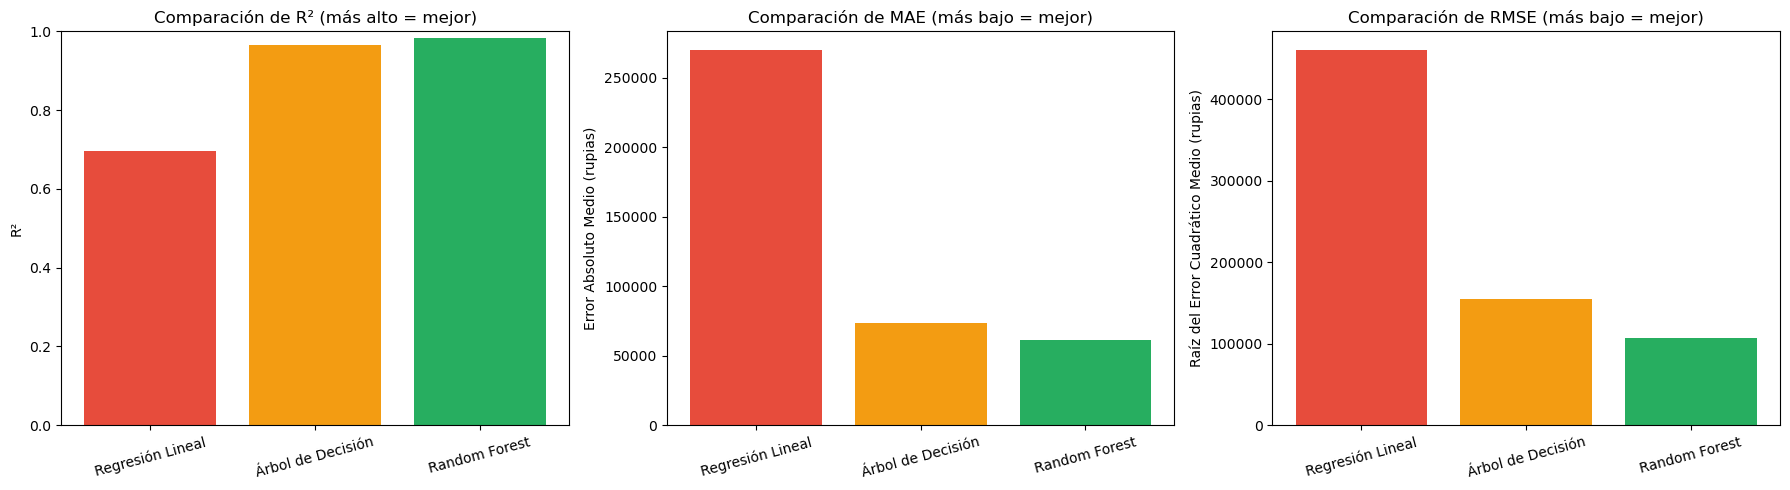

In [23]:
# Gráfico de barras comparando las 3 métricas entre los 3 modelos.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colores = ['#e74c3c', '#f39c12', '#27ae60']  # rojo, naranja, verde

# Gráfico 1: R2 (más alto = mejor)
axes[0].bar(tabla_resultados['Modelo'], tabla_resultados['R2'], color=colores)
axes[0].set_title('Comparación de R² (más alto = mejor)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

# Gráfico 2: MAE (más bajo = mejor)
axes[1].bar(tabla_resultados['Modelo'], tabla_resultados['MAE'], color=colores)
axes[1].set_title('Comparación de MAE (más bajo = mejor)')
axes[1].set_ylabel('Error Absoluto Medio (rupias)')
axes[1].tick_params(axis='x', rotation=15)

# Gráfico 3: RMSE (más bajo = mejor)
axes[2].bar(tabla_resultados['Modelo'], tabla_resultados['RMSE'], color=colores)
axes[2].set_title('Comparación de RMSE (más bajo = mejor)')
axes[2].set_ylabel('Raíz del Error Cuadrático Medio (rupias)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

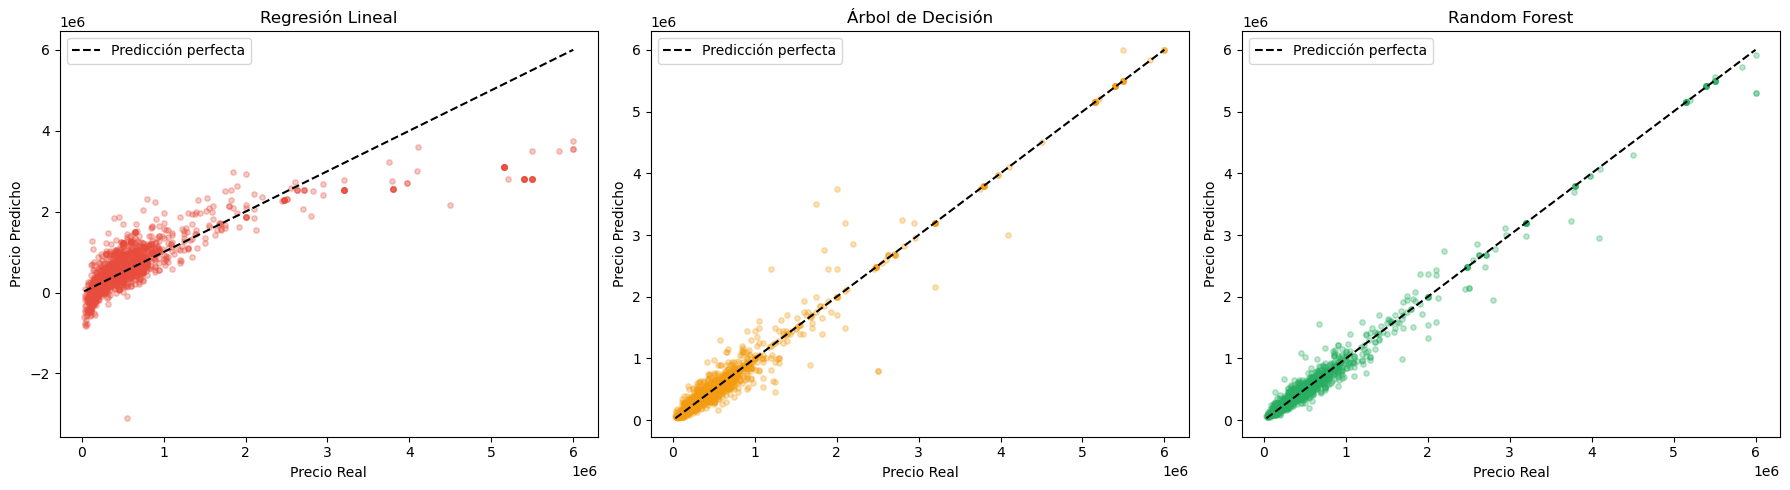

In [24]:
# Grafico de Comparación: Real vs Prediccion del Modelo

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predicciones = [pred_lineal, pred_arbol, pred_forest]
nombres = ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest']

for i, (pred, nombre) in enumerate(zip(predicciones, nombres)):
    axes[i].scatter(y_test, pred, alpha=0.3, color=colores[i], s=15)
    # Línea diagonal de referencia: donde predicción = valor real
    lims = [y_test.min(), y_test.max()]
    axes[i].plot(lims, lims, 'k--', linewidth=1.5, label='Predicción perfecta')
    axes[i].set_xlabel('Precio Real')
    axes[i].set_ylabel('Precio Predicho')
    axes[i].set_title(nombre)
    axes[i].legend()

plt.tight_layout()
plt.show()

Al mirar las gráficas se puede observar que el modelo más acertado siempre fue Random Forest, esto debido a que me permitió capturar relaciones no lineales entre los datos

Funcionaría igual al Arbol de Decisiones, sólo que se evita el sobreajuste de los árboles, siendo más efectivo que la baseline (Regresion Lineal) ya que esta es muy simple y comete menos errores que el Arbol de Decisiones. 

A pesar de que es computacionalmente mas caro (Demorandose 2.4 segundos vs la baseline que está en 0.2 segundos), la regresión lineal falla en no poder establecer relaciones que no sean lineales y valoriza los carros de manera más alta (No puede establecer que existe una relación que mientras mayor sea el kilometraje y los años menor será el valor)